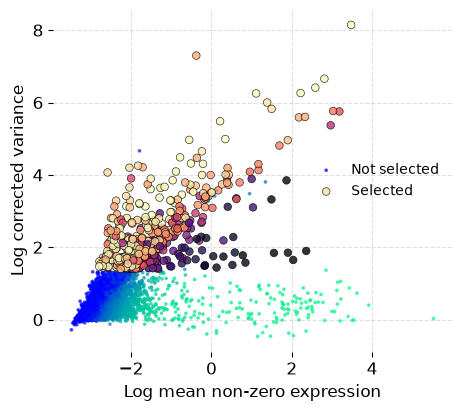

In [1]:
import numpy as np
import scarf
import scarf.plotting as splt

scarf.set_verbosity('WARNING')

scarf.fetch_dataset(
    'tenx_5K_pbmc_rnaseq',
    save_path='scarf_datasets',
    as_zarr=True,
)
ds = scarf.DataStore(
    'scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr',
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key='hvgs', k=11, dims=15, n_centroids=100)
ds.run_umap(n_epochs=150, spread=5, min_dist=1, parallel=True)
ds.run_leiden_clustering(resolution=0.5)
ds.run_marker_search(group_key='RNA_leiden_cluster', gene_batch_size=100)

In [2]:
markers = ds.get_markers(
    group_key='RNA_leiden_cluster',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1,
)
markers.head(10)

,group_id,feature_name,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,feature_index
0,1,ADTRP,0.63735,0.04209,0.00253,0.23982,0.01819,16.65120,3.978681e-115,4118
1,1,TSHZ2,0.60998,0.07359,0.00894,0.33282,0.04168,8.23648,5.086389e-138,11958
2,1,ANKRD55,0.58411,0.02175,0.00090,0.14835,0.00720,24.04471,2.254761e-76,3609
3,1,CHRM3-AS2,0.51966,0.06741,0.00749,0.38125,0.05381,9.00329,4.170388e-156,1366
4,1,AC005842.1,0.51202,0.02518,0.00251,0.15911,0.01781,10.04141,2.990642e-65,8111
5,1,TCEA3,0.51109,0.03161,0.00379,0.20984,0.03031,8.33439,1.394313e-78,213
6,1,CMTM8,0.48864,0.04742,0.00878,0.30592,0.06707,5.39966,7.543586e-93,2406
7,1,FHIT,0.48300,0.14135,0.01297,0.60876,0.09132,10.89459,8.430365e-285,2632
8,1,MAL,0.45094,0.18676,0.02926,0.68101,0.14437,6.38204,3.168063e-266,1774
9,1,DPYSL4,0.44754,0.01396,0.00053,0.10146,0.00417,26.51694,3.349421e-53,8071


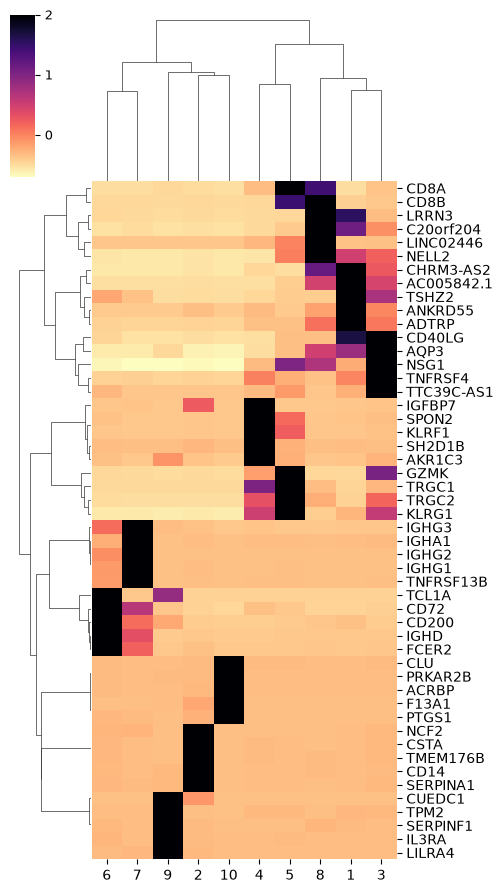

PlotResult(axes=4, tables=2, legends=1, scales=2, owns_figure=True, rendered=True)

In [3]:
splt.marker_heatmap(
    ds,
    group_key='RNA_leiden_cluster',
    topn=5,
    figsize=(5, 9),
)

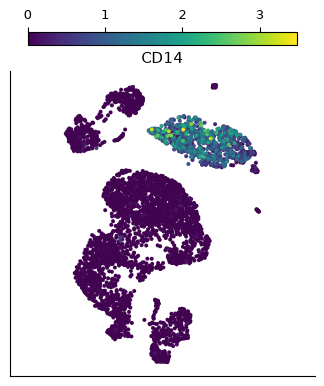

PlotResult(axes=1, tables=0, legends=1, scales=1, owns_figure=True, rendered=True)

In [4]:
splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='CD14',
    sort_values=True,
)

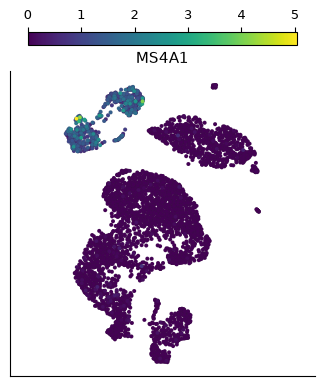

PlotResult(axes=1, tables=0, legends=1, scales=1, owns_figure=True, rendered=True)

In [5]:
splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='MS4A1',
    sort_values=True,
)

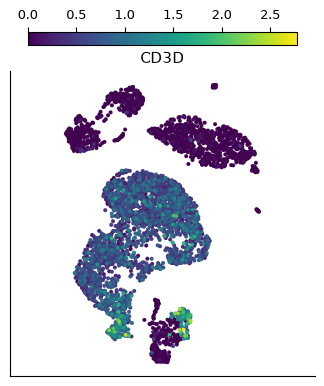

PlotResult(axes=1, tables=0, legends=1, scales=1, owns_figure=True, rendered=True)

In [6]:
splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='CD3D',
    sort_values=True,
)

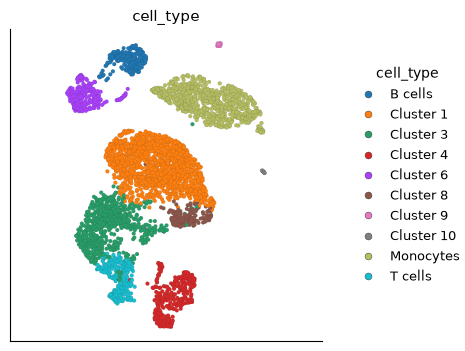

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [7]:
cluster_ids = ds.cells.fetch_all('RNA_leiden_cluster')
unique = sorted(
    {str(c) for c in cluster_ids},
    key=lambda x: (0, int(x)) if x.isdigit() else (1, x),
)

markers = ds.get_markers(
    group_key='RNA_leiden_cluster',
    group_id=None,
    min_score=-1,
    min_frac_exp=-1,
)

label_map = {c: f'Cluster {c}' for c in unique}
for gene, name in [('CD14', 'Monocytes'), ('MS4A1', 'B cells'), ('CD3D', 'T cells')]:
    hit = markers[markers['feature_name'].astype(str) == gene]
    if hit.empty:
        continue
    cid = str(hit.sort_values('score', ascending=False).iloc[0]['group_id'])
    label_map[cid] = name

labels = np.array([label_map[str(c)] for c in cluster_ids], dtype=object)
ds.cells.insert(column_name='cell_type', values=labels, overwrite=True)
splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='cell_type',
)

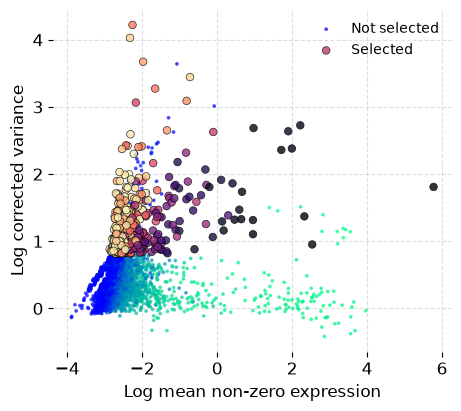

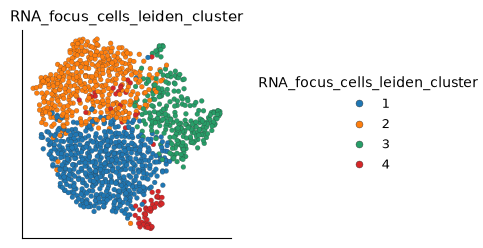

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [8]:
clusters = ds.cells.to_pandas_dataframe(
    columns=['RNA_leiden_cluster'],
    key='I',
)['RNA_leiden_cluster'].astype(str)
focus = str(clusters.value_counts().index[0])
subset = np.array([str(c) == focus for c in ds.cells.fetch_all('RNA_leiden_cluster')])
active = ds.cells.fetch_all('I').astype(bool)
ds.cells.insert('focus_cells', active & subset, overwrite=True)
# Feature keys are resolved as <cell_key>__<feat_key>. Recompute HVGs for the subset.
ds.mark_hvgs(cell_key='focus_cells', min_cells=10, top_n=500)

ds.make_graph(
    cell_key='focus_cells',
    feat_key='hvgs',
    k=11,
    dims=15,
    n_centroids=50,
)
ds.run_umap(
    cell_key='focus_cells',
    n_epochs=100,
    spread=5,
    min_dist=1,
    parallel=True,
    label='UMAP',
)
ds.run_leiden_clustering(
    cell_key='focus_cells',
    resolution=0.4,
    label='leiden_cluster',
)
# With cell_key != 'I', columns are RNA_<cell_key>_<label>
splt.embedding(
    ds,
    layout_key='RNA_focus_cells_UMAP',
    color_by='RNA_focus_cells_leiden_cluster',
    cell_key='focus_cells',
)